# Übung 1
## Das Perzeptron

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ITI-THM/EiDL/blob/master/docs/1-uebung/Perceptron.ipynb)

In dieser Übung werden Sie ein einfaches **Perzeptron** implementieren - den grundlegenden Baustein neuronaler Netze. Wie in der Vorlesung besprochen, ist das Perzeptron ein mathematisches Modell eines Neurons und dient zur binären Klassifikation.

Die Übung besteht aus zwei Teilen:
1. Implementierung eines Perzeptrons von Grund auf mit NumPy
2. Implementierung eines Perzeptrons mit PyTorch

Ziel ist es, das Perzeptron auf einem einfachen Datensatz zu trainieren und die Entscheidungsgrenze zu visualisieren.

## Teil 1: Perzeptron von Grund auf implementieren

Zunächst implementieren wir ein Perzeptron ohne spezielle Deep-Learning-Bibliotheken, nur mit NumPy.

In [58]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Current only to get "nicer" plots
import seaborn as sns
sns.set_theme()

### 1.1 Daten erstellen und Visualisieren


Erstellen Sie eine Funktion zum visualisieren der Daten

In [59]:
def visualize_data(X, y):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(X[y==0,0], X[y==0,1], color="red", label="false")
    ax.scatter(X[y==1,0], X[y==1,1], color="green", label="true")
    ax.legend()
    ax.set_xlabel("f1")
    ax.set_ylabel("f2")
    plt.show()

Erstellen Sie Daten für die Logischen Operationen AND und OR.

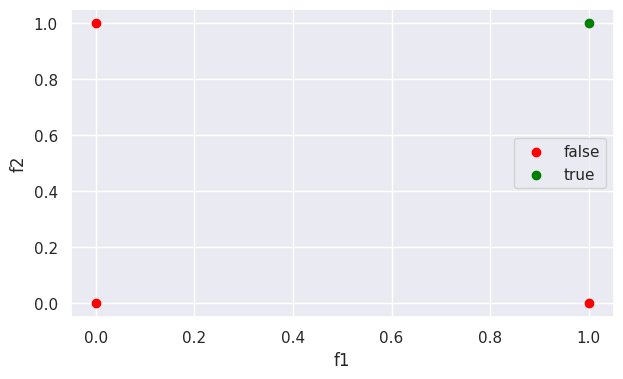

In [60]:
# Input data (features) for AND and OR operations
# X = ?
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# TODO: Define the input data for the AND and OR operations

# Output data (labels) for the AND operation
y_and = np.array([0, 0, 0, 1])
# TODO: Define the output data for the AND operation

# Output data (labels) for the OR operation
y_or = np.array([0, 1, 1, 1])
# TODO: Define the output data for the OR operation

# Select one of the operations for this exercise
y = y_and  # Change to y_or to train the OR operation

# Visualize data
visualize_data(X, y)

### 1.2 Aktivierungsfunktion definieren

Das Perzeptron verwendet eine Aktivierungsfunktion, um die Ausgabe zu berechnen. Wir implementieren die Sigmoid-Funktion und ihre Ableitung (für den Lernalgorithmus).

Sigmoid:
$$ f(x)=\frac{1}{1+e^{-x}} $$

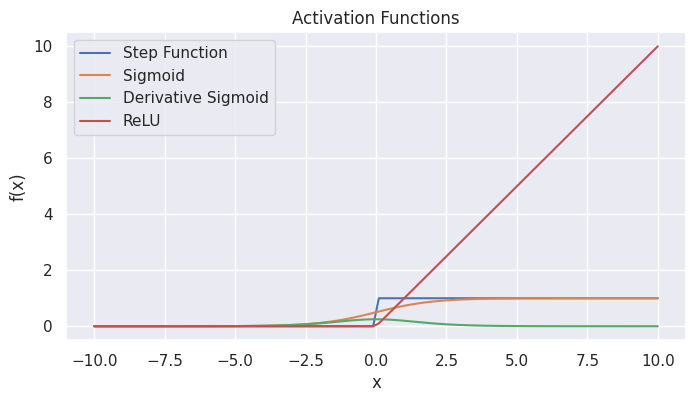

In [61]:
def step_function(x):
    # TODO: Implement the threshold function
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    """Sigmoid-Aktivierungsfunktion"""
    # TODO: Implement the Sigmoid-Funktion
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

def ReLU(x):
    # TODO: Implement the ReLU-Aktivierungsfunktion
    return np.maximum(0, x)

# Visualization of Activation Functions
x = np.linspace(-10, 10, 100)
plt.figure(figsize=(8, 4))

# TODO: Plot the activation functions
plt.plot(x, step_function(x), label='Step Function')
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, d_sigmoid(x), label = 'Derivative Sigmoid')
plt.plot(x, ReLU(x), label='ReLU')

plt.grid(True)
plt.title('Activation Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

### 1.3 Perzeptron-Klasse implementieren

Jetzt implementieren wir die Perzeptron-Klasse von Grund auf.

In [62]:
class Perzeptron:
    def __init__(self, input_size, activation_function, d_activation_function):
        """
        Initializes a perceptron with random weights and bias.

        Args:
        input_size: Number of input features
        """
        # TODO: Random initialization of weights and biases
        self.rng = np.random.default_rng(42)

        self.weights = self.rng.random(input_size)
        self.bias = self.rng.uniform()
        self.activation_function = activation_function
        self.d_activation_function = d_activation_function


    def forward(self, X):

      """
      Calculates the perceptron output for an input X.
      Args:
      X: Input data, Shape(n_samples, n_features)

      Returns:
      Perceptron output, Shape(n_samples, 1)
      """
      # TODO: Implementiere den Forward-Pass
      # z= wx + b
      z= np.dot(X, self.weights) + self.bias
      y_hat = self.activation_function(z)
      return y_hat

    def bce(self, y, y_hat):
        epsilon = 1e-15 # Adding an epsilon to avoid log(0)
        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
        return - (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def d_bce(self, y, y_hat):
        epsilon = 1e-15
        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
        return - (y / y_hat) + ((1 - y) / (1 - y_hat))


    def train(self, X, y, learning_rate=0.1, epochs=1000):
        """
        Trains the perceptron using gradient descent.

        Args:
        X: Input data, Shape(n_samples, n_features)

        Y: Target data, Shape(n_samples, 1)

        Learning rate: Learning rate

        Epochs: Number of training epochs
        Returns:
        List of loss values ​​for each epoch
        """
        loss_history = []

        for epoch in range(epochs):
            epoch_loss = 0
            for xi, yi in zip(X,y):
                # TODO: Calculate output
                y_hat= self.forward(xi)
                z = np.dot(xi, self.weights) + self.bias

                # TODO: Calculate loss
                epoch_loss += self.bce(yi, y_hat)

                # Chain Rule, backpropagation
                # dL/dy_hat local derivatives
                dL_dyhat = self.d_bce(yi, y_hat)
                # dy_hat/dz
                dyhat_dz = self.d_activation_function(z)

                # Combined error term (gradient at the output)
                delta = dL_dyhat * dyhat_dz

                # TODO: Update weights and bias
                # dL/dw = delta * x
                self.weights -= learning_rate * delta * xi
                self.bias -= learning_rate * delta

            avg_loss = epoch_loss / len(X)
            loss_history.append(avg_loss)

            # Print status every 100 epochs
            if epoch % 100 == 0:
                print(f'Epoche {epoch}: Verlust = {avg_loss:.4f}')

        return loss_history

### 1.4 Perzeptron trainieren

In [63]:
# Erstelle und trainiere ein Perzeptron
# Was is die input_size? # =number of features
# input_size = ?

input_size= X.shape[1]

model = Perzeptron(input_size=input_size, activation_function=sigmoid, d_activation_function=d_sigmoid)
loss_history = model.train(X, y, learning_rate=0.1, epochs=1000)

Epoche 0: Verlust = 1.1389
Epoche 100: Verlust = 0.2599
Epoche 200: Verlust = 0.1679
Epoche 300: Verlust = 0.1240
Epoche 400: Verlust = 0.0981
Epoche 500: Verlust = 0.0809
Epoche 600: Verlust = 0.0688
Epoche 700: Verlust = 0.0597
Epoche 800: Verlust = 0.0528
Epoche 900: Verlust = 0.0472


In [64]:
# Create a function to visualize the training process
def visualize_training(loss_history):
    # TODO: Visualisiere den Trainingsprozess
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, label='Loss')
    plt.title('Perceptron Training Process')
    plt.xlabel('Epoche')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

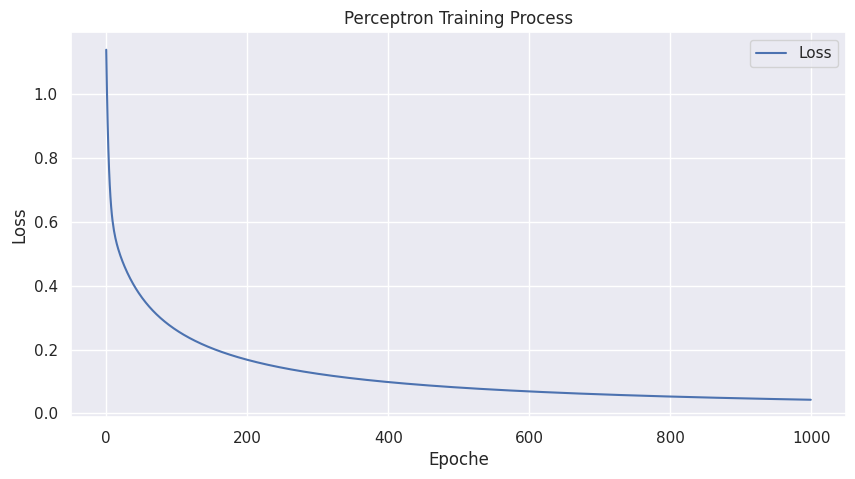

In [65]:
# Visualize the progression of the loss
visualize_training(loss_history)

### 1.5 Ergebnisse auswerten

In [66]:
predictions = model.forward(X)
print("Eingaben und Vorhersagen:")
for i in range(len(X)):
    print(f"Eingabe: {X[i]}, Erwartete Ausgabe: {y[i]:.1f}, Vorhersage: {predictions[i]:.4f}")

Eingaben und Vorhersagen:
Eingabe: [0 0], Erwartete Ausgabe: 0.0, Vorhersage: 0.0002
Eingabe: [0 1], Erwartete Ausgabe: 0.0, Vorhersage: 0.0487
Eingabe: [1 0], Erwartete Ausgabe: 0.0, Vorhersage: 0.0490
Eingabe: [1 1], Erwartete Ausgabe: 1.0, Vorhersage: 0.9330


### 1.6 Entscheidungsgrenze visualisieren

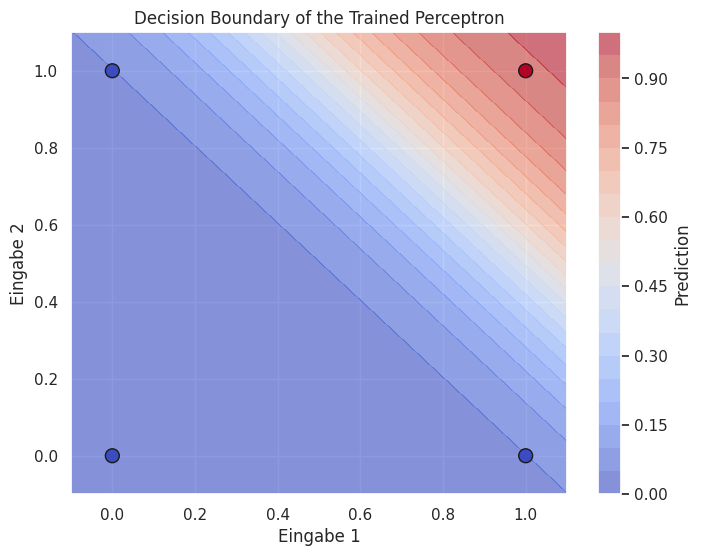

In [67]:
# Create a grid of points
x1 = np.linspace(-0.1, 1.1, 100)
x2 = np.linspace(-0.1, 1.1, 100)
x1_grid, x2_grid = np.meshgrid(x1, x2)
x_grid = np.c_[x1_grid.flatten(), x2_grid.flatten()]

# Predictions for the Grid
y_grid = model.forward(x_grid).reshape(100, 100)

# Visualization of the Decision Boundary
plt.figure(figsize=(8, 6))
contour = plt.contourf(x1_grid, x2_grid, y_grid, levels=20, cmap='coolwarm', alpha=0.6)
plt.colorbar(contour, label='Prediction')
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), s=100, edgecolors='k', cmap='coolwarm', label='Trainingsdaten')
plt.grid(True)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('Eingabe 1')
plt.ylabel('Eingabe 2')
plt.title('Decision Boundary of the Trained Perceptron')
plt.show()

## Teil 2: Perzeptron mit PyTorch implementieren

Nachdem wir ein Perzeptron von Grund auf implementiert haben, verwenden wir nun PyTorch - eine moderne Deep-Learning-Bibliothek, die automatisches Differenzieren unterstützt.

In [68]:
# PyTorch importieren
import torch
import torch.nn as nn
import torch.optim as optim

### 2.1 Daten in PyTorch-Tensoren konvertieren

In [69]:
# Converting NumPy Arrays to PyTorch Tensors
# TODO: Convert X and y into PyTorch tensors
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

print("PyTorch-Tensor für X:")
print(X_tensor)
print("\nPyTorch-Tensor für y:")
print(y_tensor)

PyTorch-Tensor für X:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

PyTorch-Tensor für y:
tensor([0., 0., 0., 1.])


### 2.2 Perzeptron-Modell in PyTorch definieren

In [70]:
class PyTorchPerzeptron(nn.Module):
    def __init__(self, input_size):
        """
        Initialisiert ein Perzeptron mit PyTorch.

        Args:
            input_size: Anzahl der Eingabefeatures
        """
        super(PyTorchPerzeptron, self).__init__()
        # Doku zu nn https://pytorch.org/docs/stable/nn.html

        # TODO: Definieren der Architektur mit input_size Eingaben und 1 Ausgabe
        # Hint: Es handelt sich hier um eine einfache lineare Schicht wx+b
        # nn.Linear(in_features, out_features)
        self.linear = nn.Linear(input_size, 1)

        # TODO: Definiere die Aktivierungsfunktion (zunächst Sigmoid)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward-Pass durch das Perzeptron.

        Args:
            x: Eingabetensor

        Returns:
            Ausgabe des Perzeptrons
        """
        # TODO: Implementiere den Forward-Pass
        # Pass input through the linear layer, then through sigmoid
        z = self.linear(x)
        output = self.sigmoid(z)
        return output

# Modell initialisieren
# input_size = ?
input_size = X_tensor.shape[1]
model_pytorch = PyTorchPerzeptron(input_size)

# Modellstruktur ausgeben
print("Modellarchitektur:")
print(model_pytorch)

Modellarchitektur:
PyTorchPerzeptron(
  (linear): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### 2.3 Modell mit PyTorch trainieren

Epoche 0: Verlust = 0.6252
Epoche 100: Verlust = 0.4478
Epoche 200: Verlust = 0.3530
Epoche 300: Verlust = 0.2944
Epoche 400: Verlust = 0.2539
Epoche 500: Verlust = 0.2239
Epoche 600: Verlust = 0.2005
Epoche 700: Verlust = 0.1816
Epoche 800: Verlust = 0.1660
Epoche 900: Verlust = 0.1529


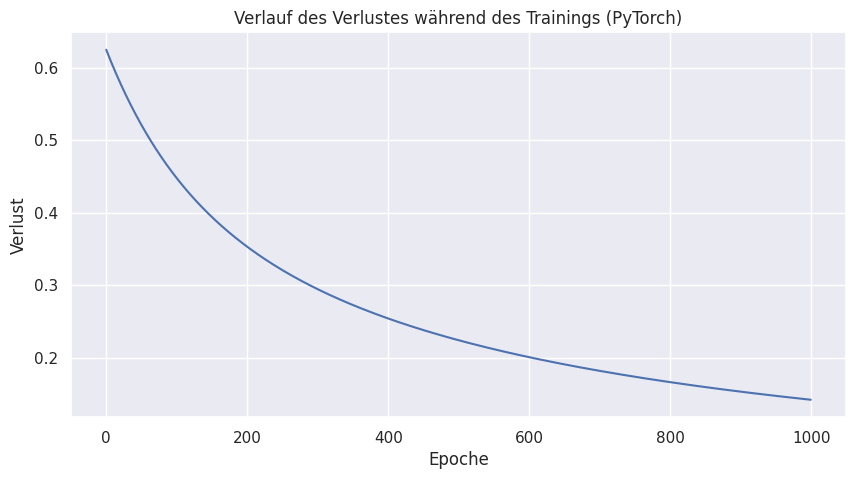

In [71]:
# Verlustfunktion definieren (Binary Cross Entropy für binäre Klassifikation)
loss_function = nn.BCELoss()

# Optimizer definieren (Stochastic Gradient Descent)
optimizer = optim.SGD(model_pytorch.parameters(), lr=0.1)

# Anzahl der Trainingsepochen
epochs = 1000

# Trainingsschleife
pytorch_loss_history = []

for epoch in range(epochs):
    # Forward-Pass: Vorhersage des Modells
    y_pred = model_pytorch(X_tensor)

    # Berechnung des Verlusts
    loss = loss_function(y_pred, y_tensor.view(-1, 1))
    pytorch_loss_history.append(loss.item())

    # Zurücksetzen der Gradienten
    optimizer.zero_grad()

    # Backward-Pass: Berechnung der Gradienten
    loss.backward()

    # Updating the Weights
    optimizer.step()

    # Alle 100 Epochen Status ausgeben
    if epoch % 100 == 0:
        print(f'Epoche {epoch}: Verlust = {loss.item():.4f}')

# Verlauf des Verlustes visualisieren
plt.figure(figsize=(10, 5))
plt.plot(pytorch_loss_history)
plt.grid(True)
plt.xlabel('Epoche')
plt.ylabel('Verlust')
plt.title('Verlauf des Verlustes während des Trainings (PyTorch)')
plt.show()

### 2.4 Ergebnisse auswerten

In [72]:
# Vorhersagen mit dem trainierten PyTorch-Modell
with torch.no_grad():
    predictions_pytorch = model_pytorch(X_tensor)
    print("Eingaben und Vorhersagen (PyTorch):")
    for i in range(len(X)):
        print(f"Eingabe: {X[i]}, Erwartete Ausgabe: {y[i]:.1f}, Vorhersage: {predictions_pytorch[i].item():.4f}")

Eingaben und Vorhersagen (PyTorch):
Eingabe: [0 0], Erwartete Ausgabe: 0.0, Vorhersage: 0.0081
Eingabe: [0 1], Erwartete Ausgabe: 0.0, Vorhersage: 0.1472
Eingabe: [1 0], Erwartete Ausgabe: 0.0, Vorhersage: 0.1492
Eingabe: [1 1], Erwartete Ausgabe: 1.0, Vorhersage: 0.7885


### 2.5 Entscheidungsgrenze visualisieren

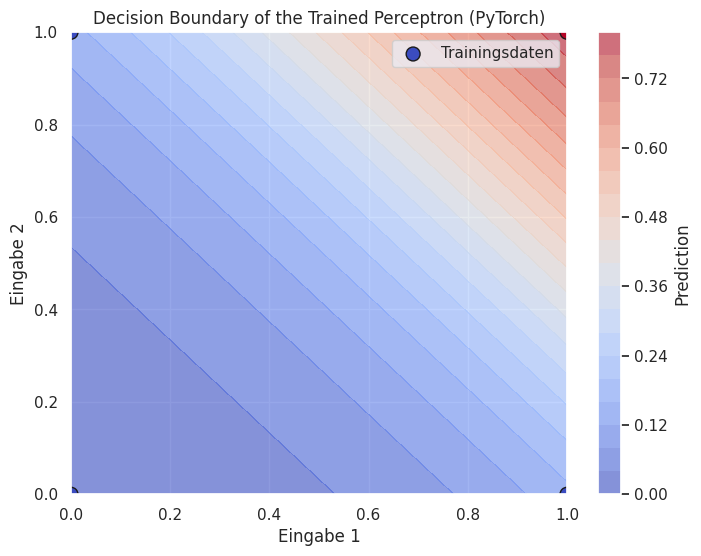

In [73]:
# Erstelle ein Raster von Punkten
x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)
x1_grid, x2_grid = np.meshgrid(x1, x2)
x_grid = np.c_[x1_grid.flatten(), x2_grid.flatten()]
x_grid_tensor = torch.FloatTensor(x_grid)

# Vorhersagen für das Raster mit PyTorch
with torch.no_grad():
    y_grid_pytorch = model_pytorch(x_grid_tensor).numpy().reshape(100, 100)

# Visualisierung der Entscheidungsgrenze
plt.figure(figsize=(8, 6))
contour = plt.contourf(x1_grid, x2_grid, y_grid_pytorch, levels=20, cmap='coolwarm', alpha=0.6)
plt.colorbar(contour, label='Prediction')
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), s=100, edgecolors='k', cmap='coolwarm', label='Trainingsdaten')
plt.grid(True)
plt.xlabel('Eingabe 1')
plt.ylabel('Eingabe 2')
plt.title('Decision Boundary of the Trained Perceptron (PyTorch)')
plt.legend()
plt.show()

### 2.6 Gewichte des Perzeptrons untersuchen

Gelernte Gewichte (PyTorch): [[3.0723271 3.056901 ]]
Gelernter Bias (PyTorch): [-4.813339]


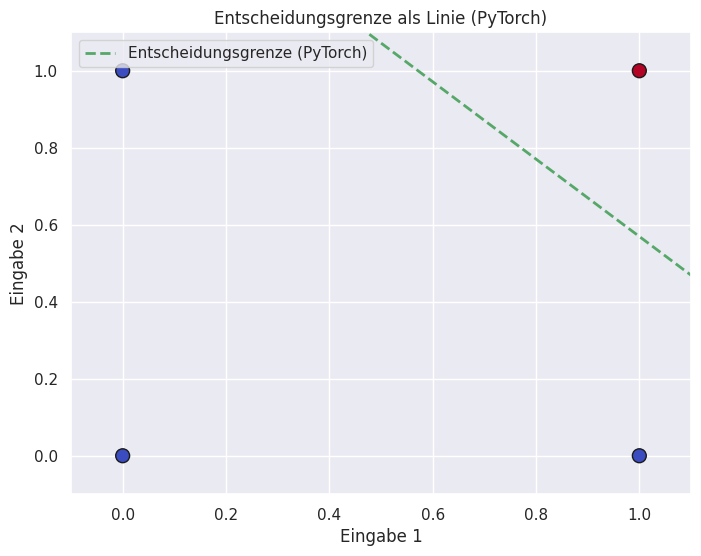

In [74]:
# Extract weights and biases from the PyTorch model
weights_pytorch = model_pytorch.linear.weight.data.numpy()
bias_pytorch = model_pytorch.linear.bias.data.numpy()

print(f"Gelernte Gewichte (PyTorch): {weights_pytorch}")
print(f"Gelernter Bias (PyTorch): {bias_pytorch}")

# Calculation of the decision boundary in the form: w1*x1 + w2*x2 + b = 0
# The line is given by: x2 = (-w1*x1 - b) / w2
def decision_boundary_pytorch(x):
    return (-weights_pytorch[0, 0] * x - bias_pytorch[0]) / weights_pytorch[0, 1]

# Visualize the decision boundary as a line
x_values = np.linspace(-0.1, 1.1, 100)
y_values_pytorch = decision_boundary_pytorch(x_values)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), s=100, edgecolors='k', cmap='coolwarm')
plt.plot(x_values, y_values_pytorch, 'g--', linewidth=2, label='Entscheidungsgrenze (PyTorch)')
plt.grid(True)
plt.xlabel('Eingabe 1')
plt.ylabel('Eingabe 2')
plt.title('Entscheidungsgrenze als Linie (PyTorch)')
plt.legend()
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.show()

## Vergleich der Ergebnisse und Diskussion

Vergleichen Sie die Ergebnisse beider Implementierungen:

1. Sind die gelernten Gewichte und Bias ähnlich?
2. Sind die Entscheidungsgrenzen ähnlich?
3. Welche Vorteile bietet die PyTorch-Implementierung?
4. Was ist der Unterschied im Code zwischen beiden Implementierungen?

### Bonusaufgaben

1. Implementieren Sie das Perzeptron für die XOR-Operation. Warum funktioniert das nicht? Was brauchen wir, um XOR zu lernen?
2. Experimentieren Sie mit verschiedenen Lernraten. Wie wirkt sich das auf das Training aus?
3. Implementieren Sie ein mehrschichtiges neuronales Netz (MLP) mit PyTorch, das die XOR-Operation lernen kann.
---
1. Implement a perceptron for the XOR operation. Why does this not work? What do we need to learn XOR?
2. Experiment with different learning rates. How does this affect the training process?
3. Implement a multilayer perceptron (MLP) using PyTorch that can learn the XOR operation.


----For XOR data, it is mathematically impossible to draw one straight line that separates the 1s from the 0s. The data is not linearly separable.

In [75]:
# Bonusaufgabe 1: XOR-Operation
# Ausgabedaten für XOR-Operation
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # Hidden layer 2 inputs -> 2 neurons
        self.hidden = nn.Linear(2, 2)
        # Output layer 2 hidden neurons -> 1 output
        self.output = nn.Linear(2, 1)
        # Activation function
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

model = MLP()

criterion = nn.BCELoss() # loss func
optimizer = optim.SGD(model.parameters(), lr=0.5) # higher LR helps XOR converge faster

# Training
epochs = 5000
for epoch in range(epochs):
    # Forward pass
    predictions = model(X_xor)
    loss = criterion(predictions, y_xor)

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("\nFinal Predictions:")
with torch.no_grad():
    test_out = model(X_xor)
    print(test_out.round()) # rounds probabilities to 0 or 1

Epoch [1000/5000], Loss: 0.3821
Epoch [2000/5000], Loss: 0.3561
Epoch [3000/5000], Loss: 0.3519
Epoch [4000/5000], Loss: 0.3502
Epoch [5000/5000], Loss: 0.3493

Final Predictions:
tensor([[0.],
        [1.],
        [0.],
        [1.]])
